In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
CATEGORIES = ["Data Science", "Machine Learning", "LLM", "AI Engineer", "AI Agents"]
PLATFORMS = ["Amazon", "AbeBooks"]
FORMATS = ["Hardcover", "Paperback", "Ebook"]


In [3]:
dates = pd.date_range("2024-01-01", "2024-12-31", freq="D")
len(dates)


366

In [4]:
np.random.seed(42)

rows = []

for date in dates:
    for category in CATEGORIES:
        for platform in PLATFORMS:

            book_format = np.random.choice(FORMATS, p=[0.2, 0.4, 0.4])

            # Typical price range for technical books
            price = np.random.uniform(25, 65)

            # Amazon tends to have higher unit velocity than AbeBooks
            base_units = 8 if platform == "Amazon" else 3
            units_sold = np.random.poisson(base_units)

            # Platform fee assumptions (can be edited)
            platform_fee_pct = 0.30 if platform == "Amazon" else 0.15

            # Printing cost per unit for physical formats
            printing_cost_per_unit = 6.0 if book_format != "Ebook" else 0.0

            # Marketing spend per day per category/platform
            marketing_spend = np.random.uniform(20, 120)

            gross_revenue = price * units_sold
            platform_fees = gross_revenue * platform_fee_pct
            printing_cost_total = printing_cost_per_unit * units_sold

            # Optional: KU / engagement simulation (ebooks only)
            page_reads = (units_sold * np.random.randint(120, 380)) if book_format == "Ebook" else 0

            # Marketing funnel simulation
            ad_clicks = np.random.poisson(40)
            conversion_rate = (units_sold / ad_clicks) if ad_clicks > 0 else 0

            total_costs = platform_fees + printing_cost_total + marketing_spend
            net_profit = gross_revenue - total_costs
            profit_margin_pct = (net_profit / gross_revenue * 100) if gross_revenue > 0 else 0

            rows.append([
                date, category, platform, book_format, price, units_sold,
                gross_revenue, platform_fee_pct, platform_fees,
                printing_cost_per_unit, printing_cost_total,
                marketing_spend, ad_clicks, conversion_rate,
                page_reads, total_costs, net_profit, profit_margin_pct
            ])

cols = [
    "date", "category", "platform", "format", "price", "units_sold",
    "gross_revenue", "platform_fee_pct", "platform_fees",
    "printing_cost_per_unit", "printing_cost_total",
    "marketing_spend", "ad_clicks", "conversion_rate",
    "page_reads", "total_costs", "net_profit", "profit_margin_pct"
]

df = pd.DataFrame(rows, columns=cols)
df.head()


,date,category,platform,format,price,units_sold,gross_revenue,platform_fee_pct,platform_fees,printing_cost_per_unit,printing_cost_total,marketing_spend,ad_clicks,conversion_rate,page_reads,total_costs,net_profit,profit_margin_pct
0,2024-01-01,Data Science,Amazon,Paperback,63.028572,6,378.171434,0.30,113.451430,6.0,36.0,90.807258,47,0.127660,0,240.258688,137.912746,36.468314
1,2024-01-01,Data Science,AbeBooks,Hardcover,32.336180,3,97.008541,0.15,14.551281,6.0,18.0,81.185289,32,0.093750,0,113.736571,-16.728029,-17.243873
2,2024-01-01,Machine Learning,Amazon,Paperback,43.242799,6,259.456796,0.30,77.837039,6.0,36.0,26.505159,46,0.130435,0,140.342198,119.114598,45.909223
3,2024-01-01,Machine Learning,AbeBooks,Hardcover,52.369321,2,104.738642,0.15,15.710796,6.0,12.0,23.438852,50,0.040000,0,51.149648,53.588994,51.164492
4,2024-01-01,LLM,Amazon,Ebook,37.468443,10,374.684430,0.30,112.405329,0.0,0.0,24.522729,38,0.263158,3320,136.928058,237.756372,63.455098


In [5]:
df.shape, df.isna().sum().sum()


((3660, 18), np.int64(0))

In [6]:
df.describe(include="all")


,date,category,platform,format,price,units_sold,gross_revenue,platform_fee_pct,platform_fees,printing_cost_per_unit,printing_cost_total,marketing_spend,ad_clicks,conversion_rate,page_reads,total_costs,net_profit,profit_margin_pct
count,3660,3660,3660,3660,3660.000000,3660.000000,3660.000000,3660.00000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000
unique,NaN,5,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Data Science,Amazon,Ebook,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,732,1830,1478,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2024-07-01 12:00:00,NaN,NaN,NaN,44.954691,5.581148,250.531650,0.22500,64.794870,3.577049,20.044262,69.999953,39.871585,0.143369,552.509563,154.839085,95.692564,20.916375
min,2024-01-01 00:00:00,NaN,NaN,NaN,25.012283,0.000000,0.000000,0.15000,0.000000,0.000000,0.000000,20.002052,21.000000,0.000000,0.000000,20.201557,-119.859019,-342.892680
25%,2024-04-01 00:00:00,NaN,NaN,NaN,34.993405,3.000000,118.676570,0.15000,18.448530,0.000000,0.000000,44.753950,36.000000,0.071429,0.000000,98.453466,13.838950,10.320236
50%,2024-07-01 12:00:00,NaN,NaN,NaN,45.073358,5.000000,215.699643,0.22500,45.203461,6.000000,12.000000,70.485762,40.000000,0.127660,0.000000,138.041608,77.985008,35.759740
75%,2024-10-01 00:00:00,NaN,NaN,NaN,54.827190,8.000000,350.107900,0.30000,101.757784,6.000000,36.000000,94.910157,44.000000,0.204082,903.000000,202.254659,158.043333,49.119919
max,2024-12-31 00:00:00,NaN,NaN,NaN,64.978427,20.000000,1141.086249,0.30000,342.325875,6.000000,120.000000,119.989267,68.000000,0.666667,5550.000000,504.342505,661.197395,80.003453


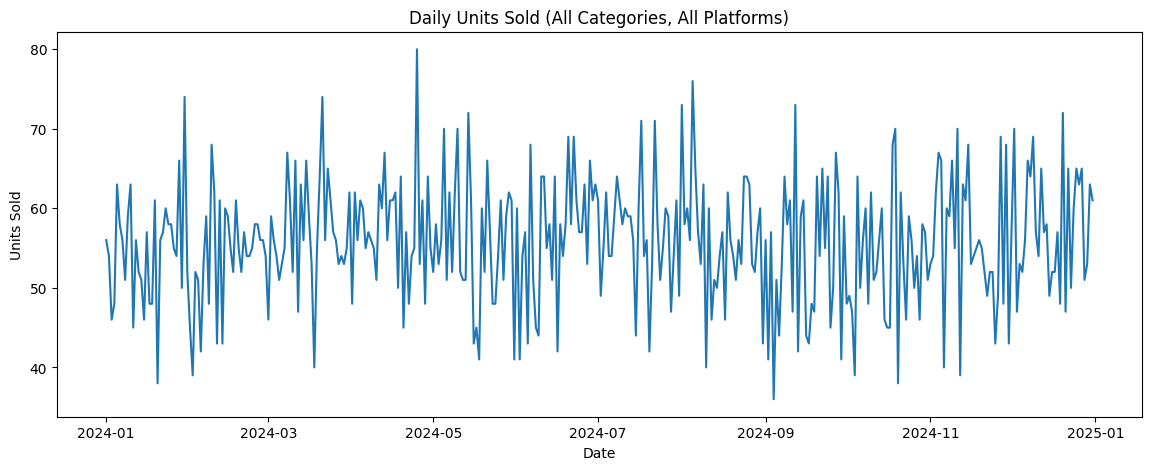

In [7]:
daily_units = df.groupby("date")["units_sold"].sum()

plt.figure(figsize=(14,5))
plt.plot(daily_units.index, daily_units.values)
plt.title("Daily Units Sold (All Categories, All Platforms)")
plt.ylabel("Units Sold")
plt.xlabel("Date")
plt.show()


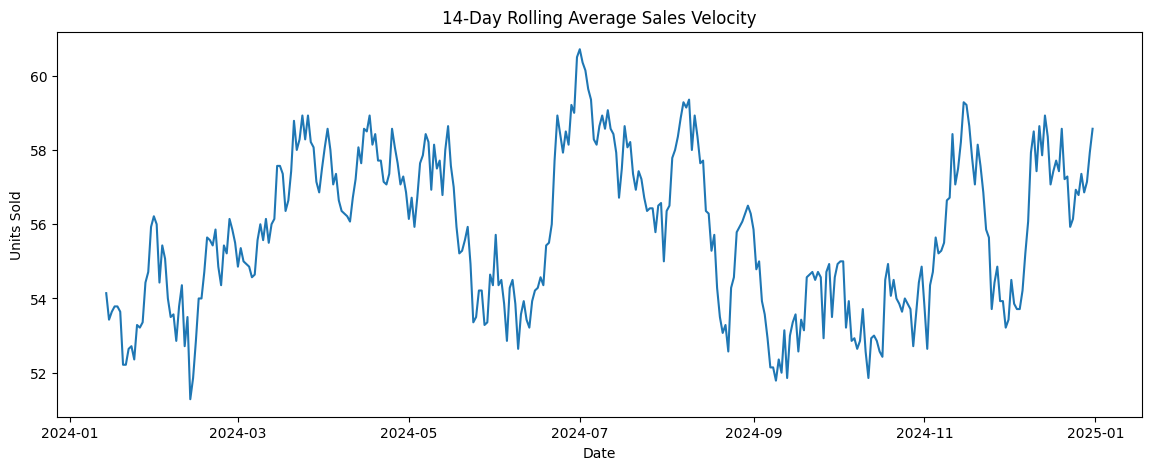

In [8]:
rolling_14 = daily_units.rolling(14).mean()

plt.figure(figsize=(14,5))
plt.plot(rolling_14.index, rolling_14.values)
plt.title("14-Day Rolling Average Sales Velocity")
plt.ylabel("Units Sold")
plt.xlabel("Date")
plt.show()


In [9]:
platform_summary = df.groupby("platform")[["units_sold", "gross_revenue", "net_profit", "marketing_spend"]].sum()
platform_summary


,units_sold,gross_revenue,net_profit,marketing_spend
platform,,,,
AbeBooks,5632,252896.848895,66091.307081,128927.014480
Amazon,14795,664048.989046,284143.478668,127272.813664


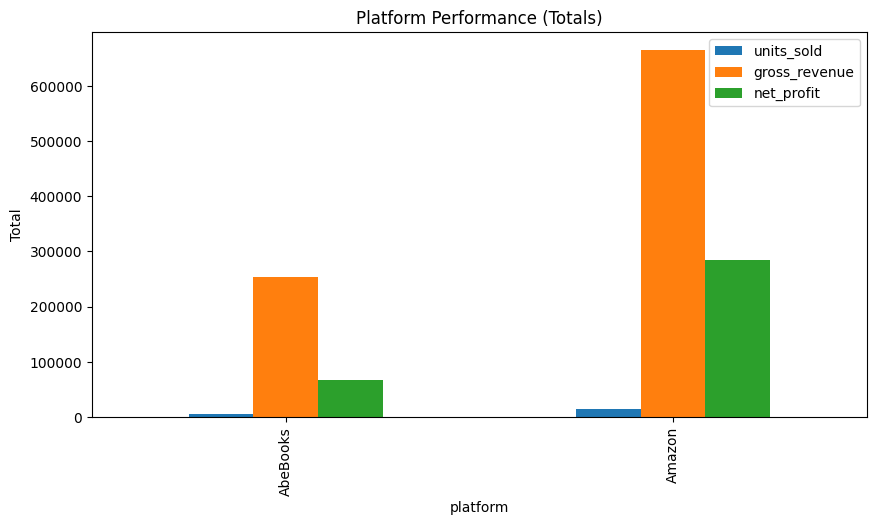

In [10]:
platform_summary[["units_sold","gross_revenue","net_profit"]].plot(kind="bar", figsize=(10,5))
plt.title("Platform Performance (Totals)")
plt.ylabel("Total")
plt.show()


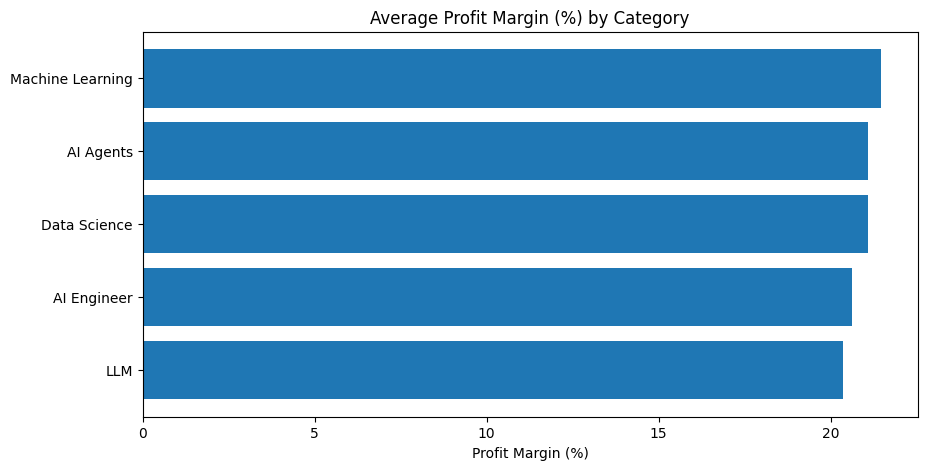

In [11]:
margin_by_cat = df.groupby("category")["profit_margin_pct"].mean().sort_values()

plt.figure(figsize=(10,5))
plt.barh(margin_by_cat.index, margin_by_cat.values)
plt.title("Average Profit Margin (%) by Category")
plt.xlabel("Profit Margin (%)")
plt.show()


In [12]:
roi_by_platform = df.groupby("platform").apply(lambda x: x["net_profit"].sum() / x["marketing_spend"].sum())
roi_by_platform


/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_15140/1585464068.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  roi_by_platform = df.groupby("platform").apply(lambda x: x["net_profit"].sum() / x["marketing_spend"].sum())


platform
AbeBooks    0.512626
Amazon      2.232554
dtype: float64

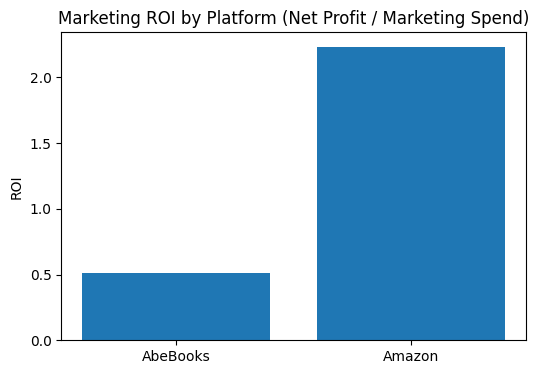

In [13]:
plt.figure(figsize=(6,4))
plt.bar(roi_by_platform.index, roi_by_platform.values)
plt.title("Marketing ROI by Platform (Net Profit / Marketing Spend)")
plt.ylabel("ROI")
plt.show()


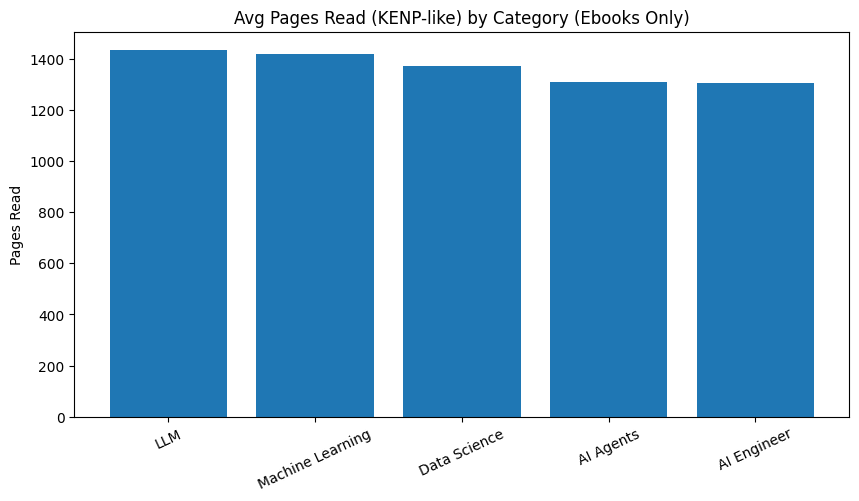

In [14]:
ebooks = df[df["format"] == "Ebook"]
kenp_by_cat = ebooks.groupby("category")["page_reads"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
plt.bar(kenp_by_cat.index, kenp_by_cat.values)
plt.title("Avg Pages Read (KENP-like) by Category (Ebooks Only)")
plt.ylabel("Pages Read")
plt.xticks(rotation=25)
plt.show()


In [15]:
df.to_csv("ai_books_sales_dataset_amazon_abebooks.csv", index=False)
print("Saved: ai_books_sales_dataset_amazon_abebooks.csv")


Saved: ai_books_sales_dataset_amazon_abebooks.csv
